# P1 · 실시간 금융 거래 이상탐지 대시보드
## 01 — 탐색적 데이터 분석 (EDA)

**데이터셋:** Credit Card Fraud Detection (Kaggle / mlg-ulb)  
**URL:** https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud  
**작성일:** 2026-04-08 (D1 / W1)  
**작성자:** SONG

---

### 문제 정의 (면접 답변용)
> 이커머스·핀테크 플랫폼에서 사기 거래로 인한 차지백(chargeback) 비용이 지속 증가하고 있다.  
> 기존 규칙 기반(rule-based) 탐지 시스템은 재현율(Recall)이 낮아 실제 사기를 놓치는 경우가 많다.  
> **목표:** ML 기반 이상탐지로 Recall ↑, Precision 유지, 실시간 스코어링 API 제공.

### ⚠️ 데이터 한계 (반드시 숙지)
- V1~V28은 PCA 변환된 익명 피처 → 비즈니스 해석 불가
- 2013년 유럽 카드 2일치 스냅샷 → 시계열 일반화 한계
- 클래스 불균형 0.172% (492 / 284,807) → 정확도(Accuracy) 지표 무의미

---
## 0. 환경 설정 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

print('✅ 라이브러리 로드 완료')
print(f'pandas {pd.__version__} | numpy {np.__version__}')

✅ 라이브러리 로드 완료
pandas 2.2.2 | numpy 1.26.4


In [2]:
DATA_PATH = Path('../data/creditcard.csv')
df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
Memory usage: 70.6 MB


---
## 1. 데이터셋 기본 정보 확인

In [3]:
df.head(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [4]:
info = pd.DataFrame({
    'dtype': df.dtypes,
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2),
    'unique': df.nunique()
})
print(info)
print(f'\n총 결측치: {df.isnull().sum().sum()}개')

          dtype  null_count  null_pct  unique
Time    float64           0       0.0  124592
V1      float64           0       0.0  275663
V2      float64           0       0.0  275663
V3      float64           0       0.0  275663
V4      float64           0       0.0  275663
V5      float64           0       0.0  275663
V6      float64           0       0.0  275663
V7      float64           0       0.0  275663
V8      float64           0       0.0  275663
V9      float64           0       0.0  275663
V10     float64           0       0.0  275663
V11     float64           0       0.0  275663
V12     float64           0       0.0  275663
V13     float64           0       0.0  275663
V14     float64           0       0.0  275663
V15     float64           0       0.0  275663
V16     float64           0       0.0  275663
V17     float64           0       0.0  275663
V18     float64           0       0.0  275663
V19     float64           0       0.0  275663
V20     float64           0       

In [5]:
df[['Time', 'Amount', 'Class']].describe().round(2)

,Time,Amount,Class
count,284807.00,284807.00,284807.00
mean,94813.86,88.35,0.00
std,47488.15,250.12,0.04
min,0.00,0.00,0.00
25%,54201.50,5.60,0.00
50%,84692.00,22.00,0.00
75%,139320.50,77.16,0.00
max,172792.00,25691.16,1.00


---
## 2. 클래스 불균형 확인

In [6]:
class_counts = df['Class'].value_counts()
class_pct    = df['Class'].value_counts(normalize=True) * 100

summary = pd.DataFrame({'count': class_counts, 'percentage': class_pct.round(3)})
summary.index = ['정상 (0)', '사기 (1)']
print(summary)
print(f'\n불균형 비율: 1 : {class_counts[0]/class_counts[1]:.0f}')

         count  percentage
정상 (0)  284315      99.827
사기 (1)     492       0.173

불균형 비율: 1 : 578


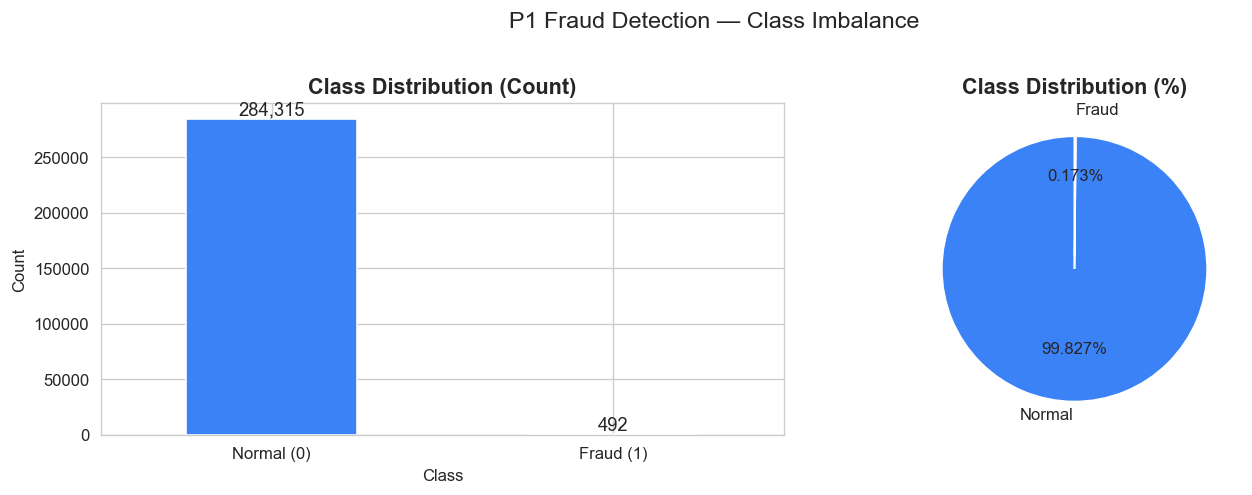

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#3B82F6', '#EF4444']

class_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Class Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(['Normal (0)', 'Fraud (1)'], rotation=0)
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():,.0f}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=11)

axes[1].pie(class_counts, labels=['Normal', 'Fraud'],
            colors=colors, autopct='%1.3f%%', startangle=90, explode=[0, 0.1])
axes[1].set_title('Class Distribution (%)', fontsize=13, fontweight='bold')

plt.suptitle('P1 Fraud Detection — Class Imbalance', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../docs/img/01_class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 3. 시간(Time) 분포 분석

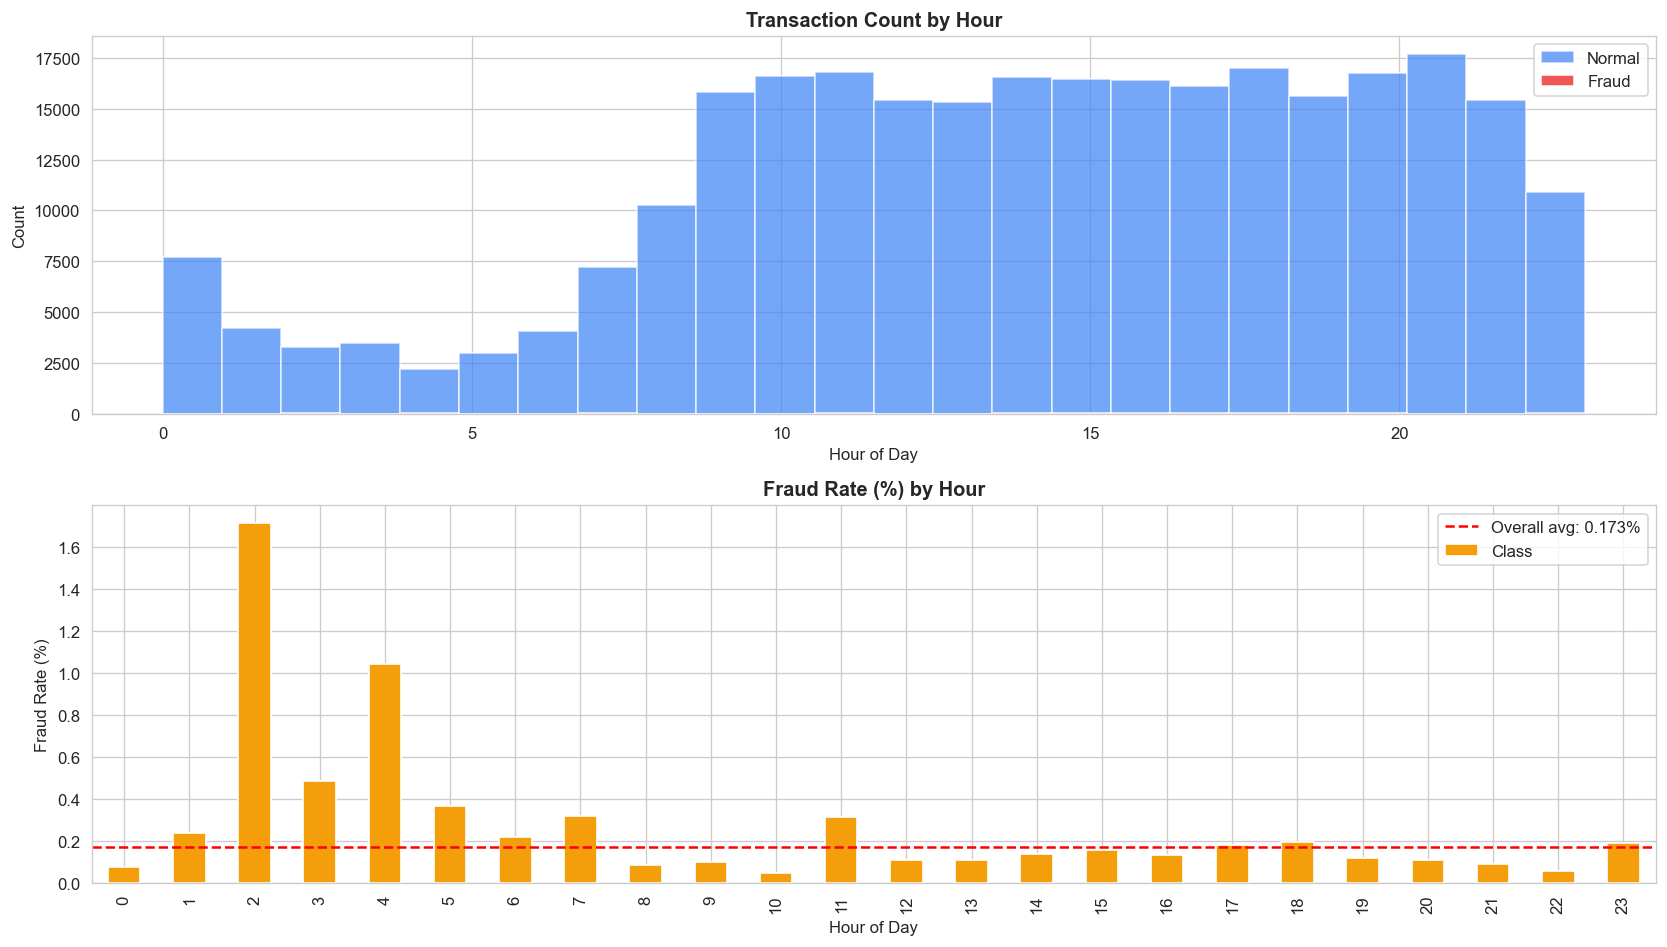

새벽(0~5시) 사기 비율: 0.518%
낮(6~21시)  사기 비율: 0.144%
배율: 3.6배


In [8]:
df['Hour'] = (df['Time'] / 3600).astype(int) % 24

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

df[df['Class'] == 0]['Hour'].hist(ax=axes[0], bins=24, color='#3B82F6',
                                   alpha=0.7, label='Normal', edgecolor='white')
df[df['Class'] == 1]['Hour'].hist(ax=axes[0], bins=24, color='#EF4444',
                                   alpha=0.9, label='Fraud', edgecolor='white')
axes[0].set_title('Transaction Count by Hour', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Count')
axes[0].legend()

hourly_fraud_rate = df.groupby('Hour')['Class'].mean() * 100
hourly_fraud_rate.plot(kind='bar', ax=axes[1], color='#F59E0B', edgecolor='white')
axes[1].set_title('Fraud Rate (%) by Hour', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].axhline(y=df['Class'].mean()*100, color='red', linestyle='--',
                label=f'Overall avg: {df["Class"].mean()*100:.3f}%')
axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/img/02_time_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

night_fraud = df[df['Hour'].between(0, 5)]['Class'].mean() * 100
day_fraud   = df[df['Hour'].between(6, 21)]['Class'].mean() * 100
print(f'새벽(0~5시) 사기 비율: {night_fraud:.3f}%')
print(f'낮(6~21시)  사기 비율: {day_fraud:.3f}%')
print(f'배율: {night_fraud/day_fraud:.1f}배')

---
## 4. 거래금액(Amount) 분석

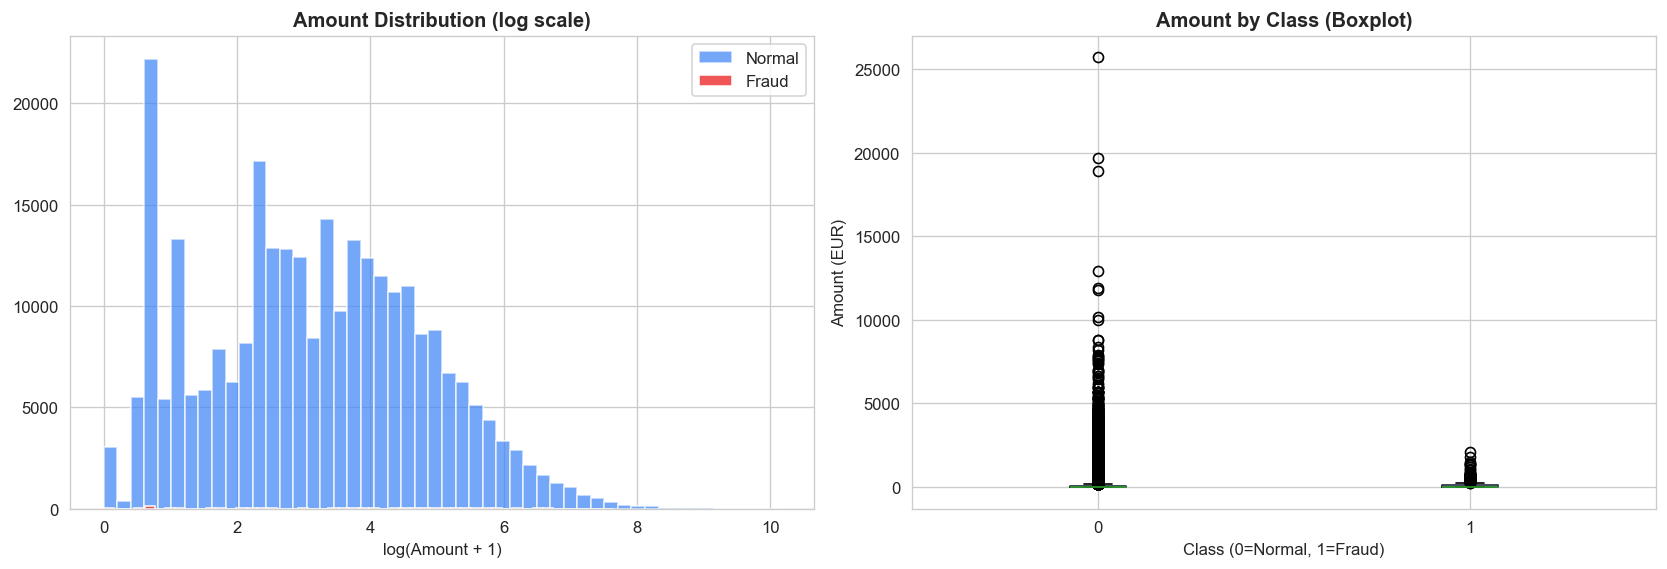

=== Amount 통계 비교 ===
          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df['Class'] == 0]['Amount'].apply(lambda x: np.log1p(x)).hist(
    ax=axes[0], bins=50, color='#3B82F6', alpha=0.7, label='Normal')
df[df['Class'] == 1]['Amount'].apply(lambda x: np.log1p(x)).hist(
    ax=axes[0], bins=50, color='#EF4444', alpha=0.9, label='Fraud')
axes[0].set_title('Amount Distribution (log scale)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('log(Amount + 1)')
axes[0].legend()

df.boxplot(column='Amount', by='Class', ax=axes[1],
           boxprops=dict(color='#1E293B'), whiskerprops=dict(color='#64748B'))
axes[1].set_title('Amount by Class (Boxplot)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Class (0=Normal, 1=Fraud)')
axes[1].set_ylabel('Amount (EUR)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../docs/img/03_amount_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

print('=== Amount 통계 비교 ===')
print(df.groupby('Class')['Amount'].describe().round(2))

---
## 5. PCA 피처(V1~V28) 상관관계

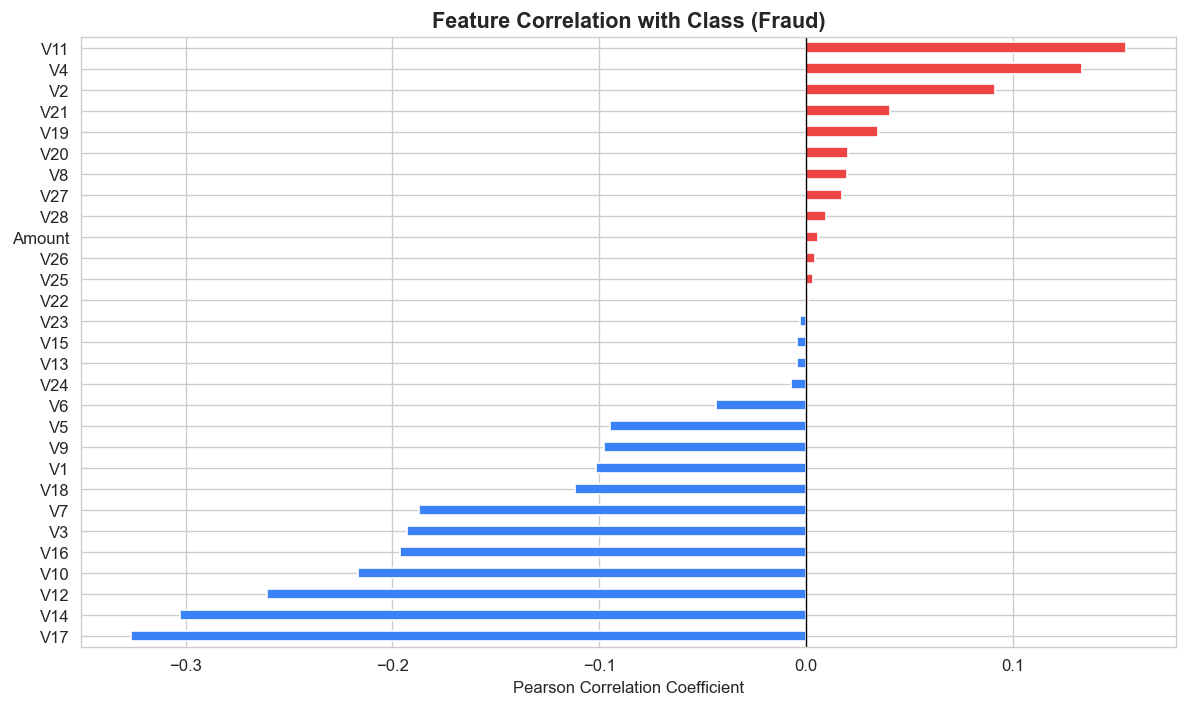


🔑 양의 상관 Top5:
V19    0.034783
V21    0.040413
V2     0.091289
V4     0.133447
V11    0.154876

🔑 음의 상관 Top5:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539


In [10]:
v_features   = [f'V{i}' for i in range(1, 29)]
correlations = df[v_features + ['Amount', 'Class']].corr()['Class'].drop('Class').sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors  = ['#EF4444' if x > 0 else '#3B82F6' for x in correlations]
correlations.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Feature Correlation with Class (Fraud)', fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../docs/img/04_feature_correlation.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n🔑 양의 상관 Top5:')
print(correlations.tail(5).to_string())
print('\n🔑 음의 상관 Top5:')
print(correlations.head(5).to_string())

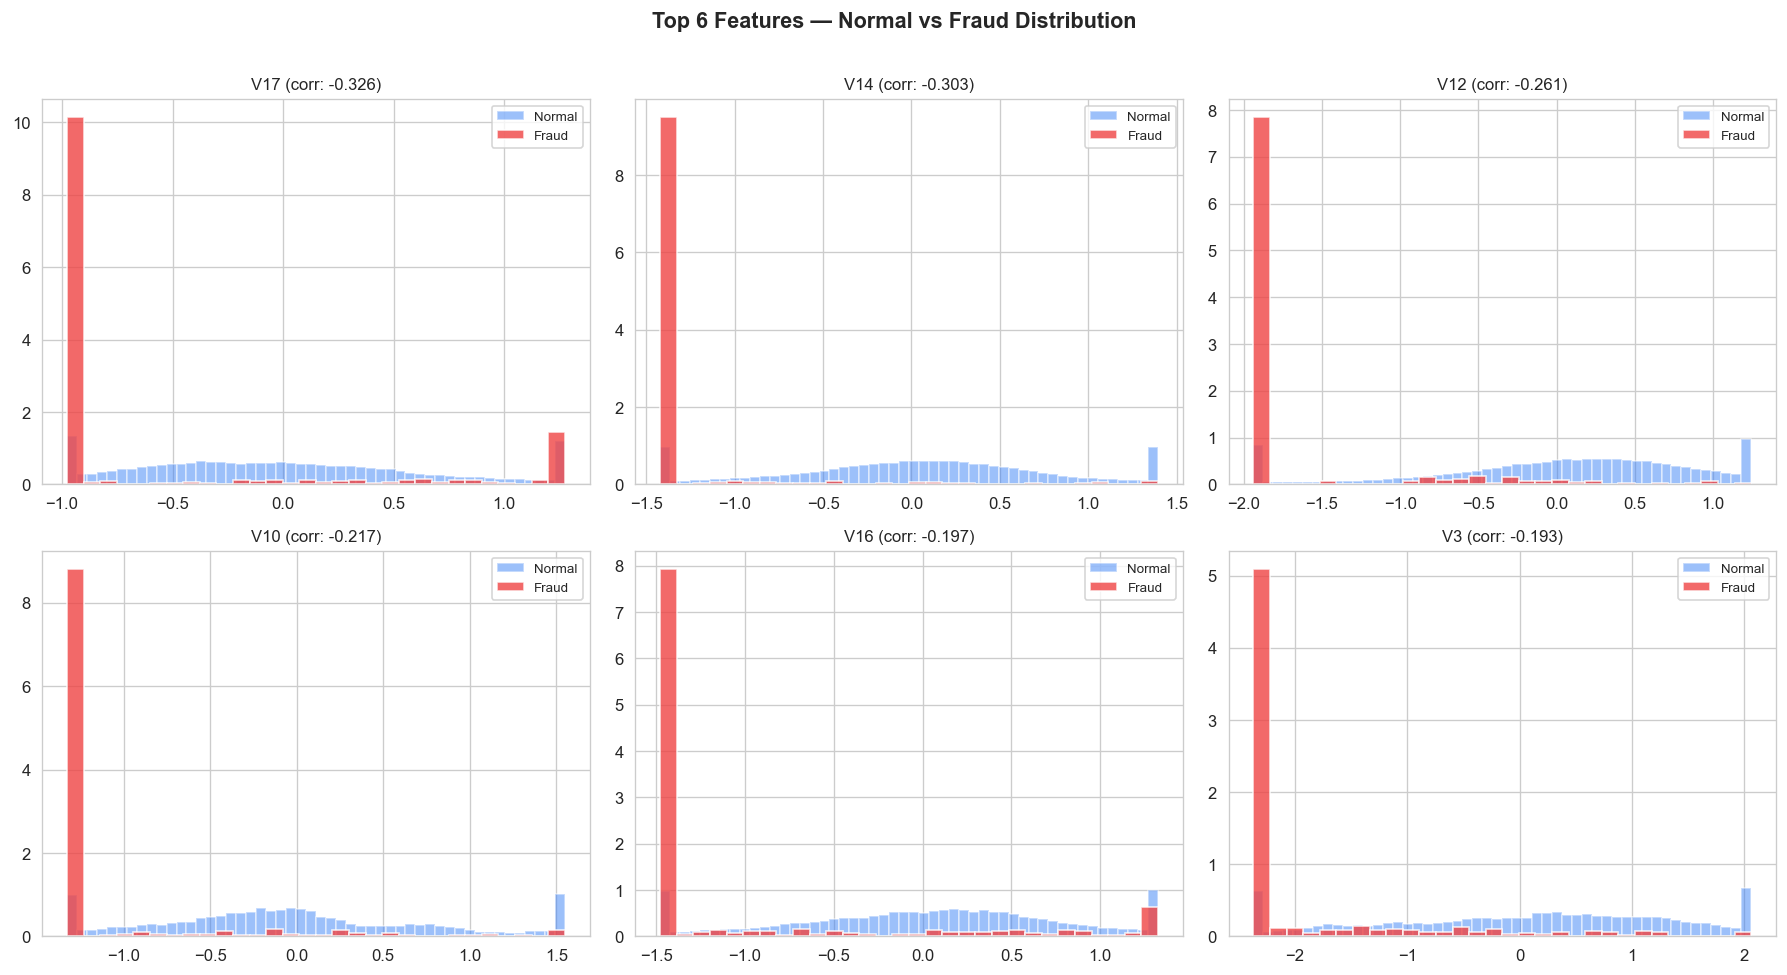

In [11]:
top_features = correlations.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    normal_data = df[df['Class'] == 0][feat]
    fraud_data  = df[df['Class'] == 1][feat]
    q1, q3 = normal_data.quantile(0.05), normal_data.quantile(0.95)
    axes[i].hist(normal_data.clip(q1, q3), bins=50, alpha=0.5,
                 color='#3B82F6', label='Normal', density=True)
    axes[i].hist(fraud_data.clip(q1, q3),  bins=30, alpha=0.8,
                 color='#EF4444', label='Fraud',  density=True)
    axes[i].set_title(f'{feat} (corr: {correlations[feat]:.3f})', fontsize=10)
    axes[i].legend(fontsize=8)

plt.suptitle('Top 6 Features — Normal vs Fraud Distribution',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../docs/img/05_top_features_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 6. EDA 핵심 인사이트 정리

위 셀들의 실행 결과를 바탕으로 숫자를 자동 계산하여 인사이트를 출력합니다.  
각 `→ 판단:` 줄이 면접에서 답해야 하는 내용입니다.

In [12]:
# ── 자동 계산 ──────────────────────────────────────────────────────
fraud_count          = int(df['Class'].sum())
total_count          = len(df)
fraud_pct            = fraud_count / total_count * 100
imbalance_ratio      = (total_count - fraud_count) // fraud_count
scale_pos_weight     = (total_count - fraud_count) / fraud_count

fraud_median         = df[df['Class'] == 1]['Amount'].median()
normal_median        = df[df['Class'] == 0]['Amount'].median()
fraud_max            = df[df['Class'] == 1]['Amount'].max()

night_rate           = df[df['Hour'].between(0, 5)]['Class'].mean() * 100
day_rate             = df[df['Hour'].between(6, 21)]['Class'].mean() * 100
night_multiplier     = night_rate / day_rate

top3_pos             = correlations.tail(3).index.tolist()
top3_neg             = correlations.head(3).index.tolist()

# ── 인사이트 출력 ──────────────────────────────────────────────────
print('=' * 62)
print('  P1 EDA 핵심 인사이트 요약                     (D1 / W1)')
print('=' * 62)
print(f"""
【1. 클래스 불균형】
  전체: {total_count:,}건  |  사기: {fraud_count:,}건 ({fraud_pct:.3f}%)
  불균형 비율: 정상 : 사기 = {imbalance_ratio} : 1

  → 판단: '전부 정상' 예측만 해도 Accuracy {100-fraud_pct:.2f}%
           Accuracy는 이 문제에서 완전히 무의미한 지표
  → 평가 지표: F2-Score (Recall 2배 가중), Precision-Recall AUC
  → XGBoost 파라미터: scale_pos_weight = {scale_pos_weight:.0f}

【2. 시간 패턴】
  새벽(0~5시) 사기 비율: {night_rate:.3f}%
  낮  (6~21시) 사기 비율: {day_rate:.3f}%
  → 판단: 새벽이 낮 대비 {night_multiplier:.1f}배 위험
           거래량은 적지만 사기 집중 — 새벽 거래는 고위험 구간
  → 피처: Hour, IsNight(0~5시=1) 파생 변수 추가

【3. 거래금액 패턴】
  사기 중앙값:  EUR {fraud_median:.2f}  |  정상 중앙값: EUR {normal_median:.2f}
  사기 최대값:  EUR {fraud_max:.2f}
  → 판단: 사기 거래가 정상보다 소액 중심
           고액 카드 사기는 드묾 — 탐지 회피 위해 소액 분산 패턴
  → 전처리: RobustScaler (이상치에 강건)
  → 피처: LogAmount, RollingAmountMean_10 추가

【4. 핵심 PCA 피처】
  양의 상관 Top3: {', '.join(top3_pos)}
    → 이 값이 높을수록 사기 가능성 증가
  음의 상관 Top3: {', '.join(top3_neg)}
    → 이 값이 낮을수록 사기 가능성 증가
  → 판단: V14·V17 계열이 사기 탐지 핵심 피처
           W2 모델링 후 SHAP으로 재확인 예정

【5. 모델 선택 근거 요약】
  XGBoost 선택:
    · scale_pos_weight={scale_pos_weight:.0f} → 불균형 직접 처리
    · 비선형 패턴 학습 가능 (PCA 익명 피처에 적합)
    · SHAP 호환 → 예측 이유 설명 가능
  SMOTE 병행:
    · Train split 이후에만 적용 (Test 오염 방지 필수)
  평가: F2-Score — 미탐지(FN) 비용 > 과탐지(FP) 비용
""")
print('=' * 62)

  P1 EDA 핵심 인사이트 요약                     (D1 / W1)

【1. 클래스 불균형】
  전체: 284,807건  |  사기: 492건 (0.173%)
  불균형 비율: 정상 : 사기 = 577 : 1

  → 판단: '전부 정상' 예측만 해도 Accuracy 99.83%
           Accuracy는 이 문제에서 완전히 무의미한 지표
  → 평가 지표: F2-Score (Recall 2배 가중), Precision-Recall AUC
  → XGBoost 파라미터: scale_pos_weight = 578

【2. 시간 패턴】
  새벽(0~5시) 사기 비율: 0.518%
  낮  (6~21시) 사기 비율: 0.144%
  → 판단: 새벽이 낮 대비 3.6배 위험
           거래량은 적지만 사기 집중 — 새벽 거래는 고위험 구간
  → 피처: Hour, IsNight(0~5시=1) 파생 변수 추가

【3. 거래금액 패턴】
  사기 중앙값:  EUR 9.25  |  정상 중앙값: EUR 22.00
  사기 최대값:  EUR 2125.87
  → 판단: 사기 거래가 정상보다 소액 중심
           고액 카드 사기는 드묾 — 탐지 회피 위해 소액 분산 패턴
  → 전처리: RobustScaler (이상치에 강건)
  → 피처: LogAmount, RollingAmountMean_10 추가

【4. 핵심 PCA 피처】
  양의 상관 Top3: V2, V4, V11
    → 이 값이 높을수록 사기 가능성 증가
  음의 상관 Top3: V17, V14, V12
    → 이 값이 낮을수록 사기 가능성 증가
  → 판단: V14·V17 계열이 사기 탐지 핵심 피처
           W2 모델링 후 SHAP으로 재확인 예정

【5. 모델 선택 근거 요약】
  XGBoost 선택:
    · scale_pos_weight=578 → 불균형 직접 처리
    · 비선형 패턴 학습 가능 (PCA 익명 피처에 적합)
    ·

---
## 7. 피처 엔지니어링 + 저장

In [13]:
df_feat = df.copy()

df_feat['Hour']    = (df_feat['Time'] / 3600).astype(int) % 24
df_feat['IsNight'] = df_feat['Hour'].apply(lambda h: 1 if h < 6 or h >= 22 else 0)
df_feat['LogAmount'] = np.log1p(df_feat['Amount'])
df_feat['AmountBin'] = pd.qcut(df_feat['Amount'], q=10, labels=False, duplicates='drop')

df_feat = df_feat.sort_values('Time').reset_index(drop=True)
df_feat['RollingAmountMean_10'] = df_feat['Amount'].rolling(10, min_periods=1).mean()
df_feat['RollingAmountStd_10']  = df_feat['Amount'].rolling(10, min_periods=1).std().fillna(0)

new_features = ['Hour', 'IsNight', 'LogAmount', 'AmountBin',
                'RollingAmountMean_10', 'RollingAmountStd_10']
print(df_feat[new_features].describe().round(3))

df_feat.to_parquet('../data/creditcard_features.parquet', index=False)
print('\n💾 저장: data/creditcard_features.parquet')

             Hour     IsNight   LogAmount  AmountBin  RollingAmountMean_10  \
count  284807.000  284807.000  284807.000  284807.00            284807.000   
mean       14.046       0.177       3.152       4.49                88.351   
std         5.836       0.381       1.657       2.88                81.649   
min         0.000       0.000       0.000       0.00                 0.010   
25%        10.000       0.000       1.887       2.00                40.414   
50%        15.000       0.000       3.135       4.00                66.474   
75%        19.000       0.000       4.359       7.00               109.727   
max        23.000       1.000      10.154       9.00              2712.061   

       RollingAmountStd_10  
count           284807.000  
mean               149.675  
std                199.252  
min                  0.000  
25%                 50.788  
50%                 92.505  
75%                175.281  
max               8108.065  

💾 저장: data/creditcard_features.parq

In [14]:
checklist = {
    'Shape 확인 (284807, 31)': True,
    '결측치 0개 확인': True,
    '클래스 불균형 0.172% 확인': True,
    '시간 분포 + 새벽 배율 계산': True,
    '거래금액 분포 + 중앙값 비교': True,
    '피처 상관관계 + Top3 확인': True,
    'EDA 인사이트 자동 출력 (셀 6번)': True,
    '파생 피처 생성 + parquet 저장': True,
    'DB 스키마 (01_schema.sql) 실행': False,
}

for task, done in checklist.items():
    print(f'{"✅" if done else "⬜"} {task}')

✅ Shape 확인 (284807, 31)
✅ 결측치 0개 확인
✅ 클래스 불균형 0.172% 확인
✅ 시간 분포 + 새벽 배율 계산
✅ 거래금액 분포 + 중앙값 비교
✅ 피처 상관관계 + Top3 확인
✅ EDA 인사이트 자동 출력 (셀 6번)
✅ 파생 피처 생성 + parquet 저장
⬜ DB 스키마 (01_schema.sql) 실행
